* **Customer Segmentation using Clustering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*  **Data Loading**

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


* **Data Understanding**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


* **Data Preprocessing**

In [5]:
data = df[['total_bill', 'tip']]
data.head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

* **Clustering (K-Means)**

In [7]:
from sklearn.cluster import KMeans

In [8]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(data_scaled)

KMeans(n_clusters=3)

In [9]:
data.loc[:, 'Cluster'] = kmeans.labels_

data.head()

/tmp/ipykernel_727/3782807886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Cluster'] = kmeans.labels_


,total_bill,tip,Cluster
0,16.99,1.01,0
1,10.34,1.66,0
2,21.01,3.50,1
3,23.68,3.31,1
4,24.59,3.61,1


* **Visualization**

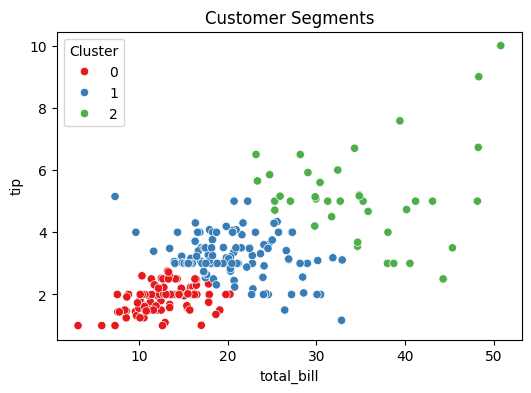

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='total_bill', y='tip', hue='Cluster', data=data, palette='Set1')
plt.title("Customer Segments")
plt.show()

* **Insights**

1. Customers are divided into 3 groups based on spending and tipping behavior.
2. One group represents low spenders, another medium, and another high spenders.
3. Higher total bill customers tend to give higher tips.
4. Clustering helps businesses target different customer groups.

* **Conclusion**

  This project used K-Means clustering to segment customers based on their spending behavior.
  The model grouped customers into different categories, helping businesses understand customer patterns and improve decision-making.